Libraries imported
Dataset Loaded

Dataset Shape:
(569, 30)

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Names:
['malignant' 'benign']

First 5 Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.

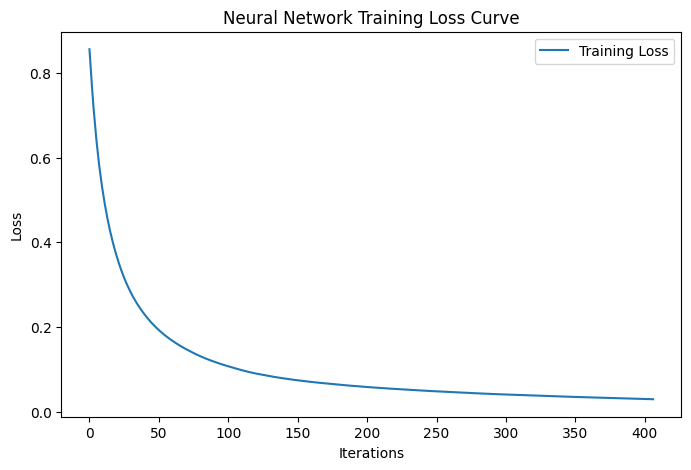

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported")

# Load Breast Cancer Dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Loaded")

print("\nDataset Shape:")
print(X.shape)

print("\nFeature Names:")
print(data.feature_names)

print("\nTarget Names:")
print(data.target_names)

# Convert dataset into DataFrame
df = pd.DataFrame(X, columns=data.feature_names)

df["target"] = y

print("\nFirst 5 Rows:")
print(df.head())

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

# Standardize the input data
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("\nData Standardized")

# Create Feed Forward Backpropagation Neural Network
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=0
)

# Train the Neural Network
model.fit(X_train, y_train)

print("\nNeural Network Model:")
print(model)

# Predict test data
y_pred = model.predict(X_test)

print("\nPredicted Test Results:")
print(y_pred)

print("\nActual Test Results:")
print(y_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy * 100, "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

# Model Score
score = model.score(X_test, y_test)

print("\nModel Test Score:", score)

# Training Loss
print("\nFinal Training Loss:", model.loss_)

# Plot Training Loss Curve
plt.figure(figsize=(8, 5))

plt.plot(
    model.loss_curve_,
    label="Training Loss"
)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss Curve")
plt.legend()
plt.show()